<a href="https://colab.research.google.com/github/aisha13dikko-sudo/using-synthetic-data-for-thermal-comfort-classification/blob/main/wk3_CTGAN_tvae_autotherm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install sdv datasets --quiet
print("✅ Installation complete!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.2/15.2 MB 131.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 103.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 12.6 MB/s eta 0:00:00
✅ Installation complete!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset
from sdv.single_table import CTGANSynthesizer
from sdv.single_table import TVAESynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, balanced_accuracy_score,
                             classification_report)
from sklearn.preprocessing import LabelEncoder
import re

print("✅ All imports ready!")

✅ All imports ready!


In [3]:
# Everything identical to GC notebook — same data, same split
print("Loading AutoTherm indoor dataset...")
dataset = load_dataset('kopetri/AutoTherm', 'indoor')
train_df = dataset['train'].to_pandas()
print(f"Loaded {len(train_df):,} rows")

# Extract participant ID
def extract_participant_id(filename):
    match = re.search(r'participant_\d+', filename)
    return match.group() if match else 'unknown'

train_df['participant_id'] = train_df['file_name'].apply(extract_participant_id)

# Add 3-class label
def add_3class(df):
    df = df.copy()
    df['Label_3class'] = df['Label'].apply(
        lambda x: -1 if x <= -2 else (0 if x <= 1 else 1)
    )
    return df

train_df = add_3class(train_df)

# Same subject-wise split as GC notebook
test_participants  = ['participant_16', 'participant_14', 'participant_20']
train_participants = [p for p in train_df['participant_id'].unique()
                      if p not in test_participants]

train_split = train_df[train_df['participant_id'].isin(train_participants)]
test_split  = train_df[train_df['participant_id'].isin(test_participants)]

print(f"Train: {len(train_split):,} rows | Test: {len(test_split):,} rows")
print(f"✅ Same subject-wise split confirmed!")

Loading AutoTherm indoor dataset...


README.md:   0%|          | 0.00/8.57k [00:00<?, ?B/s]

indoor/train-00000-of-00002.parquet:   0%|          | 0.00/29.8M [00:00<?, ?B/s]

indoor/train-00001-of-00002.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

indoor/test-00000-of-00001.parquet:   0%|          | 0.00/7.41M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1566728 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/194829 [00:00<?, ? examples/s]

Loaded 1,566,728 rows
Train: 1,276,709 rows | Test: 290,019 rows
✅ Same subject-wise split confirmed!


In [4]:
drop_cols = [
    'file_name', 'Timestamp', 'participant_id',
    'Air-Velocity', 'Metabolic-Rate',
    'Nose', 'Neck', 'RShoulder', 'RElbow',
    'LShoulder', 'LElbow', 'REye', 'LEye', 'REar', 'LEar',
    'Emotion-Self', 'Emotion-ML',
    'Label', 'Label_3class'
]

def prepare_features(df, drop_cols, target_col):
    df = df.copy()
    X = df.drop(columns=drop_cols, errors='ignore')
    y = df[target_col]
    for col in X.select_dtypes(include=['object','category']).columns:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    return X, y

def prepare_synthetic(df, feature_cols, target_col):
    X = df[feature_cols].copy()
    y = df[target_col]
    for col in X.select_dtypes(include=['object','category']).columns:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    X = X.fillna(X.median(numeric_only=True))
    return X, y

# 7-class splits
X_train_7, y_train_7 = prepare_features(train_split, drop_cols, 'Label')
X_test_7,  y_test_7  = prepare_features(test_split,  drop_cols, 'Label')

# 3-class splits
X_train_3, y_train_3 = prepare_features(train_split, drop_cols, 'Label_3class')
X_test_3,  y_test_3  = prepare_features(test_split,  drop_cols, 'Label_3class')

feature_cols = X_train_7.columns.tolist()
print(f"Features: {len(feature_cols)}")
print(f"✅ No leakage: { 'Label' not in feature_cols and 'Label_3class' not in feature_cols}")

Features: 18
✅ No leakage: True


In [5]:
print("Training baselines — takes 2-3 minutes...")

clf_base_7 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_base_7.fit(X_train_7, y_train_7)
y_pred_base_7 = clf_base_7.predict(X_test_7)
base_7_f1  = f1_score(y_test_7, y_pred_base_7, average='macro')
base_7_bal = balanced_accuracy_score(y_test_7, y_pred_base_7)

clf_base_3 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_base_3.fit(X_train_3, y_train_3)
y_pred_base_3 = clf_base_3.predict(X_test_3)
base_3_f1  = f1_score(y_test_3, y_pred_base_3, average='macro')
base_3_bal = balanced_accuracy_score(y_test_3, y_pred_base_3)

print(f"📊 BASELINE 7-class | Macro F1: {base_7_f1:.4f} | Bal Acc: {base_7_bal:.4f}")
print(f"📊 BASELINE 3-class | Macro F1: {base_3_f1:.4f} | Bal Acc: {base_3_bal:.4f}")

Training baselines — takes 2-3 minutes...
📊 BASELINE 7-class | Macro F1: 0.2858 | Bal Acc: 0.3035
📊 BASELINE 3-class | Macro F1: 0.7163 | Bal Acc: 0.6759


In [6]:
sdv_drop = [
    'file_name', 'Timestamp', 'participant_id',
    'Air-Velocity', 'Metabolic-Rate',
    'Nose', 'Neck', 'RShoulder', 'RElbow',
    'LShoulder', 'LElbow', 'REye', 'LEye', 'REar', 'LEar',
    'Emotion-Self', 'Emotion-ML',
    'Label_3class'
]

sdv_train = train_split.drop(columns=sdv_drop, errors='ignore').copy()
sdv_train['Gender'] = LabelEncoder().fit_transform(
    sdv_train['Gender'].astype(str)
)

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(sdv_train)
metadata.update_column(column_name='Label', sdtype='categorical')

print(f"SDV training data: {sdv_train.shape}")
print(f"✅ Metadata ready!")

SDV training data: (1276709, 19)
✅ Metadata ready!


In [7]:
sdv_drop = [
    'file_name', 'Timestamp', 'participant_id',
    'Air-Velocity', 'Metabolic-Rate',
    'Nose', 'Neck', 'RShoulder', 'RElbow',
    'LShoulder', 'LElbow', 'REye', 'LEye', 'REar', 'LEar',
    'Emotion-Self', 'Emotion-ML',
    'Label_3class'
]

sdv_train = train_split.drop(columns=sdv_drop, errors='ignore').copy()
sdv_train['Gender'] = LabelEncoder().fit_transform(
    sdv_train['Gender'].astype(str)
)

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(sdv_train)
metadata.update_column(column_name='Label', sdtype='categorical')

print(f"SDV training data: {sdv_train.shape}")
print(f"✅ Metadata ready!")

SDV training data: (1276709, 19)
✅ Metadata ready!


In [8]:
# CTGAN on stratified sample — 100,000 rows
# Standard practice for large datasets
# Documented in methodology as computational constraint

print("Creating stratified sample for CTGAN...")

sdv_train_sample = sdv_train.groupby('Label', group_keys=False).apply(
    lambda x: x.sample(
        n=min(len(x), int(100000 * len(x) / len(sdv_train))),
        random_state=42
    )
).reset_index(drop=True)

print(f"Sample size: {len(sdv_train_sample):,} rows")
print(f"Label distribution:")
print(sdv_train_sample['Label'].value_counts().sort_index())

# Rebuild metadata for sample
metadata_sample = SingleTableMetadata()
metadata_sample.detect_from_dataframe(sdv_train_sample)
metadata_sample.update_column(column_name='Label', sdtype='categorical')

print("\nFitting CTGAN on 100k sample — estimated 5-8 minutes on A100...")
ctgan = CTGANSynthesizer(metadata_sample, epochs=300, verbose=True)
ctgan.fit(sdv_train_sample)
print("\n✅ CTGAN fitted!")

Creating stratified sample for CTGAN...
Sample size: 99,996 rows
Label distribution:
Label
-3     3761
-2     9151
-1    20622
 0    24056
 1    13968
 2    15896
 3    12542
Name: count, dtype: int64

Fitting CTGAN on 100k sample — estimated 5-8 minutes on A100...


Gen. (-00.20) | Discrim. (-00.38): 100%|██████████| 300/300 [32:28<00:00,  6.50s/it]


✅ CTGAN fitted!


In [9]:
print("Generating synthetic data...")
ctgan_synthetic = ctgan.sample(num_rows=len(sdv_train))
print(f"✅ Generated {len(ctgan_synthetic):,} synthetic rows")

# Compare label distributions
print("\nLabel distribution — REAL:")
print(sdv_train['Label'].value_counts().sort_index())
print("\nLabel distribution — CTGAN SYNTHETIC:")
print(ctgan_synthetic['Label'].value_counts().sort_index())

# Fidelity report
print("\nRunning quality report...")
quality = evaluate_quality(sdv_train, ctgan_synthetic, metadata)

Generating synthetic data...
✅ Generated 1,276,709 synthetic rows

Label distribution — REAL:
Label
-3     48020
-2    116840
-1    263290
 0    307137
 1    178333
 2    202958
 3    160131
Name: count, dtype: int64

Label distribution — CTGAN SYNTHETIC:
Label
-3     54376
-2    109832
-1    267108
 0    298898
 1    155681
 2    252340
 3    138474
Name: count, dtype: int64

Running quality report...
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 19/19 [00:04<00:00,  4.16it/s]|
Column Shapes Score: 94.75%

(2/2) Evaluating Column Pair Trends: |██████████| 171/171 [00:22<00:00,  7.57it/s]|
Column Pair Trends Score: 86.1%

Overall Score (Average): 90.43%



In [10]:
X_ct_synth, y_ct_synth = prepare_synthetic(
    ctgan_synthetic, feature_cols, 'Label'
)

clf_ct_tstr_7 = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)
clf_ct_tstr_7.fit(X_ct_synth, y_ct_synth)
y_pred_ct_tstr_7 = clf_ct_tstr_7.predict(X_test_7)

ct_tstr_7_f1  = f1_score(y_test_7, y_pred_ct_tstr_7, average='macro')
ct_tstr_7_bal = balanced_accuracy_score(y_test_7, y_pred_ct_tstr_7)

print("📊 CTGAN TSTR — 7-class")
print(f"Macro F1:          {ct_tstr_7_f1:.4f}")
print(f"Balanced Accuracy: {ct_tstr_7_bal:.4f}")
print(f"Baseline was:      {base_7_f1:.4f}")
print(f"Difference:        {ct_tstr_7_f1 - base_7_f1:+.4f}")
print()
print(classification_report(y_test_7, y_pred_ct_tstr_7))

📊 CTGAN TSTR — 7-class
Macro F1:          0.1709
Balanced Accuracy: 0.2183
Baseline was:      0.2858
Difference:        -0.1150

              precision    recall  f1-score   support

          -3       0.00      0.00      0.00     22556
          -2       0.42      0.00      0.00     19285
          -1       0.44      0.73      0.55     85260
           0       0.13      0.11      0.12     39044
           1       0.00      0.00      0.00     16824
           2       0.32      0.63      0.43     51786
           3       0.38      0.06      0.10     55264

    accuracy                           0.35    290019
   macro avg       0.24      0.22      0.17    290019
weighted avg       0.30      0.35      0.27    290019



In [11]:
X_aug_ct_7 = pd.concat(
    [X_train_7, X_ct_synth], axis=0
).reset_index(drop=True)

y_aug_ct_7 = pd.concat([
    y_train_7.reset_index(drop=True),
    y_ct_synth.reset_index(drop=True)
], axis=0).reset_index(drop=True)

clf_ct_aug_7 = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)
clf_ct_aug_7.fit(X_aug_ct_7, y_aug_ct_7)
y_pred_ct_aug_7 = clf_ct_aug_7.predict(X_test_7)

ct_aug_7_f1  = f1_score(y_test_7, y_pred_ct_aug_7, average='macro')
ct_aug_7_bal = balanced_accuracy_score(y_test_7, y_pred_ct_aug_7)

print("📊 CTGAN AUGMENTED — 7-class")
print(f"Macro F1:          {ct_aug_7_f1:.4f}")
print(f"Balanced Accuracy: {ct_aug_7_bal:.4f}")
print(f"Baseline was:      {base_7_f1:.4f}")
print(f"Difference:        {ct_aug_7_f1 - base_7_f1:+.4f}")
print()
print(classification_report(y_test_7, y_pred_ct_aug_7))

📊 CTGAN AUGMENTED — 7-class
Macro F1:          0.1841
Balanced Accuracy: 0.2165
Baseline was:      0.2858
Difference:        -0.1017

              precision    recall  f1-score   support

          -3       0.00      0.00      0.00     22556
          -2       0.00      0.00      0.00     19285
          -1       0.42      0.71      0.53     85260
           0       0.12      0.11      0.11     39044
           1       0.07      0.02      0.03     16824
           2       0.31      0.54      0.39     51786
           3       0.53      0.14      0.23     55264

    accuracy                           0.35    290019
   macro avg       0.21      0.22      0.18    290019
weighted avg       0.30      0.35      0.28    290019



In [12]:
# Derive 3-class label from CTGAN synthetic data
ctgan_synthetic_3 = ctgan_synthetic.copy()
ctgan_synthetic_3['Label_3class'] = ctgan_synthetic_3['Label'].apply(
    lambda x: -1 if x <= -2 else (0 if x <= 1 else 1)
)

X_ct_synth_3, y_ct_synth_3 = prepare_synthetic(
    ctgan_synthetic_3, feature_cols, 'Label_3class'
)

# TSTR
clf_ct_tstr_3 = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)
clf_ct_tstr_3.fit(X_ct_synth_3, y_ct_synth_3)
y_pred_ct_tstr_3 = clf_ct_tstr_3.predict(X_test_3)

ct_tstr_3_f1  = f1_score(y_test_3, y_pred_ct_tstr_3, average='macro')
ct_tstr_3_bal = balanced_accuracy_score(y_test_3, y_pred_ct_tstr_3)

# Augmented
X_aug_ct_3 = pd.concat(
    [X_train_3, X_ct_synth_3], axis=0
).reset_index(drop=True)
y_aug_ct_3 = pd.concat([
    y_train_3.reset_index(drop=True),
    y_ct_synth_3.reset_index(drop=True)
], axis=0).reset_index(drop=True)

clf_ct_aug_3 = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)
clf_ct_aug_3.fit(X_aug_ct_3, y_aug_ct_3)
y_pred_ct_aug_3 = clf_ct_aug_3.predict(X_test_3)

ct_aug_3_f1  = f1_score(y_test_3, y_pred_ct_aug_3, average='macro')
ct_aug_3_bal = balanced_accuracy_score(y_test_3, y_pred_ct_aug_3)

print("📊 CTGAN TSTR — 3-class")
print(f"Macro F1: {ct_tstr_3_f1:.4f} | Baseline: {base_3_f1:.4f} | Diff: {ct_tstr_3_f1-base_3_f1:+.4f}")
print()
print("📊 CTGAN AUGMENTED — 3-class")
print(f"Macro F1: {ct_aug_3_f1:.4f} | Baseline: {base_3_f1:.4f} | Diff: {ct_aug_3_f1-base_3_f1:+.4f}")

📊 CTGAN TSTR — 3-class
Macro F1: 0.5040 | Baseline: 0.7163 | Diff: -0.2123

📊 CTGAN AUGMENTED — 3-class
Macro F1: 0.4925 | Baseline: 0.7163 | Diff: -0.2237


In [13]:
results = pd.DataFrame({
    'Method': [
        'Baseline',
        'GC TSTR',
        'GC Augmented',
        'CTGAN TSTR',
        'CTGAN Augmented',
    ],
    '7-class Macro F1': [
        base_7_f1,
        0.2727,   # from GC notebook
        0.2825,   # from GC notebook
        ct_tstr_7_f1,
        ct_aug_7_f1,
    ],
    '7-class Bal Acc': [
        base_7_bal,
        0.2913,
        0.3019,
        ct_tstr_7_bal,
        ct_aug_7_bal,
    ],
    '3-class Macro F1': [
        base_3_f1,
        0.4969,
        0.4932,
        ct_tstr_3_f1,
        ct_aug_3_f1,
    ],
    '3-class Bal Acc': [
        base_3_bal,
        0.5257,
        0.5220,
        ct_tstr_3_bal,
        ct_aug_3_bal,
    ],
}).round(4)

print("=" * 75)
print("FULL RESULTS — AutoTherm Indoor: Baseline + GC + CTGAN")
print("=" * 75)
print(results.to_string(index=False))

results.to_csv('wk3_ctgan_results.csv', index=False)
print("\n✅ Saved to wk3_ctgan_results.csv")

FULL RESULTS — AutoTherm Indoor: Baseline + GC + CTGAN
         Method  7-class Macro F1  7-class Bal Acc  3-class Macro F1  3-class Bal Acc
       Baseline            0.2858           0.3035            0.7163           0.6759
        GC TSTR            0.2727           0.2913            0.4969           0.5257
   GC Augmented            0.2825           0.3019            0.4932           0.5220
     CTGAN TSTR            0.1709           0.2183            0.5040           0.5243
CTGAN Augmented            0.1841           0.2165            0.4925           0.5212

✅ Saved to wk3_ctgan_results.csv


In [14]:
# ── SMOTE BASELINE COMPARISON ─────────────────────────────────────
# SMOTE = Synthetic Minority Oversampling Technique
# The classic 2002 method — comparing against it shows whether
# modern deep learning methods actually add value over a simple baseline

!pip install imbalanced-learn --quiet

from imblearn.over_sampling import SMOTE

print("Running SMOTE oversampling...")
smote = SMOTE(random_state=42, k_neighbors=5)
X_smote_7, y_smote_7 = smote.fit_resample(X_train_7, y_train_7)

print(f"Original training size: {len(X_train_7):,}")
print(f"After SMOTE:            {len(X_smote_7):,}")
print(f"\nClass distribution after SMOTE:")
print(pd.Series(y_smote_7).value_counts().sort_index())

# Train classifier on SMOTE data only (TSTR equivalent)
clf_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_smote.fit(X_smote_7, y_smote_7)
y_pred_smote = clf_smote.predict(X_test_7)

smote_f1  = f1_score(y_test_7, y_pred_smote, average='macro')
smote_bal = balanced_accuracy_score(y_test_7, y_pred_smote)

print(f"\n📊 SMOTE — 7-class")
print(f"Macro F1:          {smote_f1:.4f}")
print(f"Balanced Accuracy: {smote_bal:.4f}")
print(f"Baseline was:      {base_7_f1:.4f}")
print(classification_report(y_test_7, y_pred_smote))

Running SMOTE oversampling...
Original training size: 1,276,709
After SMOTE:            2,149,959

Class distribution after SMOTE:
Label
-3    307137
-2    307137
-1    307137
 0    307137
 1    307137
 2    307137
 3    307137
Name: count, dtype: int64

📊 SMOTE — 7-class
Macro F1:          0.2586
Balanced Accuracy: 0.2688
Baseline was:      0.2858
              precision    recall  f1-score   support

          -3       0.00      0.00      0.00     22556
          -2       0.00      0.00      0.00     19285
          -1       0.62      0.71      0.66     85260
           0       0.11      0.17      0.13     39044
           1       0.18      0.33      0.23     16824
           2       0.37      0.34      0.35     51786
           3       0.62      0.33      0.43     55264

    accuracy                           0.38    290019
   macro avg       0.27      0.27      0.26    290019
weighted avg       0.39      0.38      0.37    290019



Top 10 most important features for thermal comfort:
Ambient_Temperature       0.1744
Wrist_Skin_Temperature    0.1255
Radiation-Temp            0.1150
PCE-Ambient-Temp          0.1093
Ambient_Humidity          0.1029
GSR                       0.0850
Solar_Radiation           0.0459
Bodyfat                   0.0379
Height                    0.0327
Bodytemp                  0.0303
dtype: float64


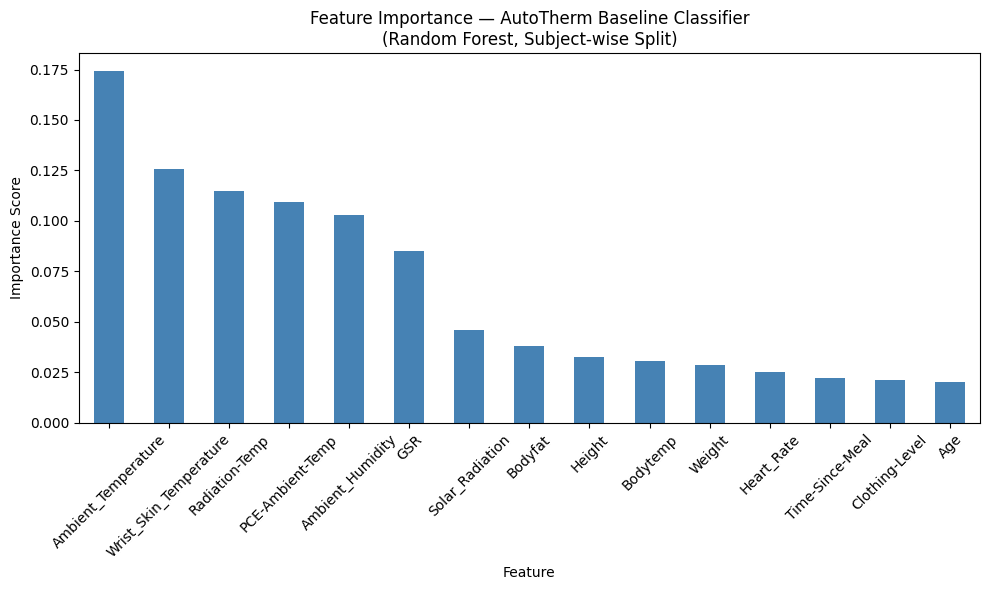

✅ Chart saved!


In [15]:
# ── FEATURE IMPORTANCE ANALYSIS ───────────────────────────────────
# Which features drive thermal comfort prediction?
# Does this explain why synthetic data struggles on certain classes?

importances = pd.Series(
    clf_base_7.feature_importances_,
    index=X_train_7.columns
).sort_values(ascending=False)

print("Top 10 most important features for thermal comfort:")
print(importances.head(10).round(4))

# Visualise
fig, ax = plt.subplots(figsize=(10, 6))
importances.head(15).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Feature Importance — AutoTherm Baseline Classifier\n(Random Forest, Subject-wise Split)')
ax.set_xlabel('Feature')
ax.set_ylabel('Importance Score')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [16]:
# Add SMOTE to your results table
results_with_smote = pd.DataFrame({
    'Method': [
        'Baseline',
        'GC TSTR',
        'GC Augmented',
        'CTGAN TSTR',
        'CTGAN Augmented',
        'SMOTE',
    ],
    '7-class Macro F1': [
        0.2858, 0.2727, 0.2825, 0.1709, 0.1841, 0.2586
    ],
    '7-class Bal Acc': [
        0.3035, 0.2913, 0.3019, 0.2183, 0.2165, 0.2688
    ],
    '3-class Macro F1': [
        0.7163, 0.4969, 0.4932, 0.5040, 0.4925, None
    ],
    '3-class Bal Acc': [
        0.6759, 0.5257, 0.5220, 0.5243, 0.5212, None
    ],
}).round(4)

print(results_with_smote.to_string(index=False))
results_with_smote.to_csv('wk3_full_results.csv', index=False)
print("\n✅ Full results saved!")

         Method  7-class Macro F1  7-class Bal Acc  3-class Macro F1  3-class Bal Acc
       Baseline            0.2858           0.3035            0.7163           0.6759
        GC TSTR            0.2727           0.2913            0.4969           0.5257
   GC Augmented            0.2825           0.3019            0.4932           0.5220
     CTGAN TSTR            0.1709           0.2183            0.5040           0.5243
CTGAN Augmented            0.1841           0.2165            0.4925           0.5212
          SMOTE            0.2586           0.2688               NaN              NaN

✅ Full results saved!
